# ANSER simulation in Python
A port of the MATLAB simulation with design considerations specific to python and future ML work.

---

### Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from coil_dimension_calc import coil_dimension_calc
from build_field_generator import build_field_generator
from field_coil_calc import field_coil_calc 
from sensor_objective_function import sensor_objective_function
from normal_vector import normal_vector
import consts
%matplotlib inline

ModuleNotFoundError: No module named 'coil_dimension_calc'

---
## Coil Geometry Plots

### Single coil in local coordinate system

In [ ]:
coil_local = coil_dimension_calc(consts.N_turns,consts.l,consts.w,consts.s,consts.z_thick)

In [ ]:
fig = plt.figure(figsize=(16,16))
ax = fig.add_subplot(111, projection='3d')
N = consts.N_turns

ax.plot3D(coil_local[:, 0], coil_local[:, 1], coil_local[:, 2], linewidth=0.25)

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.show()

### All 8 Coils in Global Coordinate System

In [ ]:
coils_global = build_field_generator(consts.N_turns,consts.l,consts.w,consts.s,consts.z_thick,consts.centres,consts.rotations)

In [ ]:
print(coils_global.shape)
coils = [f'Coil {i}' for i in range(coils_global.shape[0])]

In [ ]:
fig = plt.figure(figsize=(16,16))
ax = fig.add_subplot(111, projection='3d')
N = consts.N_turns

for i in range(coils_global.shape[0]):
    ax.plot3D(coils_global[i, :, 0], coils_global[i, :, 1], coils_global[i, :, 2], linewidth=0.5, label = coils[i])

ax.legend()
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.show()

---
## Compute H field at a test point

In [ ]:
test_point = np.array([0.05,0.05,0.01])

In [ ]:
test_field = field_coil_calc(consts.I, coils_global, test_point)

In [2]:
print(test_field)

NameError: name 'test_field' is not defined

In [3]:
test_field_norm = np.linalg.norm(test_field, axis = -1)

NameError: name 'test_field' is not defined

In [4]:
print(test_field_norm)

NameError: name 'test_field_norm' is not defined

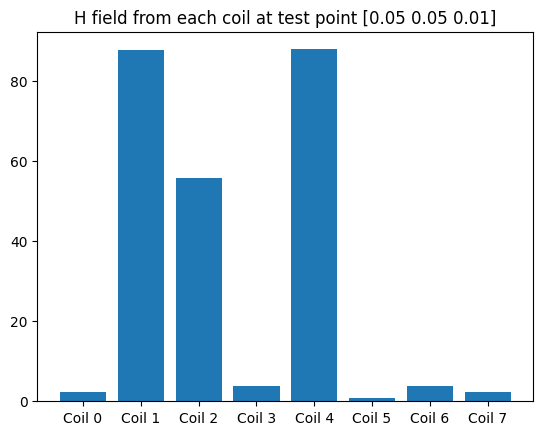

In [12]:
plt.bar(coils,test_field_norm)
plt.title(f'H field from each coil at test point {test_point}')
plt.show()

## Solve for a test point using least squares.

### Sweep over noise 

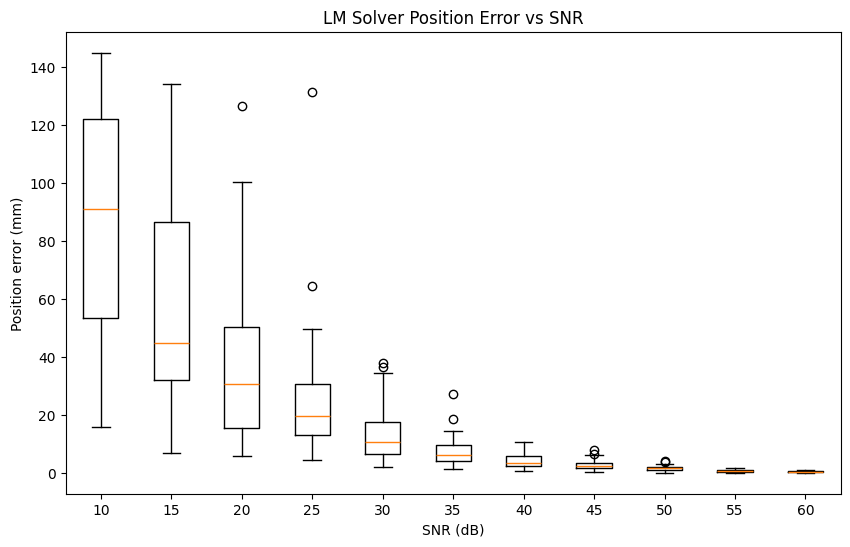

CPU times: user 24.7 s, sys: 3.98 ms, total: 24.7 s
Wall time: 24.9 s


In [18]:
%%time
from scipy.optimize import least_squares

test_PO = np.array([0.1,0.1,0.1,np.pi/3,np.pi/2])

H = field_coil_calc(consts.I,coils_global,test_PO[:3])
n = normal_vector(test_PO)

flux = consts.calibration * np.sum(H*n, axis = -1)

snrs = np.arange(10, 65, 5)
errors = []

for snr in snrs:
    errs = []
    for _ in range(50):
        flux_noisy = flux + np.sqrt(np.mean(flux**2) / 10**(snr/10)) * np.random.randn(8)
        result = least_squares(
            sensor_objective_function,
            x0=[0, 0, 0.2, 0, 0],
            bounds=([-0.5, -0.5, 0, -np.pi, -3*np.pi],
                    [0.5, 0.5, 0.5, np.pi, 3*np.pi]),
            args=(flux_noisy, coils_global, calibration),
        )
        errs.append(np.linalg.norm(result.x[:3] - p) * 1000)
    errors.append(errs)
    
plt.figure(figsize=(10, 6))
plt.boxplot(errors, tick_labels=snrs)
plt.xlabel('SNR (dB)')
plt.ylabel('Position error (mm)')
plt.title('LM Solver Position Error vs SNR')
plt.show()        




Here we did a sweep over 11 difference noise values ranging from 10 to 60. For each we do 50 simulations and count the mean error per simulation. Least squares struggles with noisy data, and takes approximately 0.05 seconds for each solve on a reasonably good computer. 